First 5 Records
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dataset Shape
(150, 5)

Column Names
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object

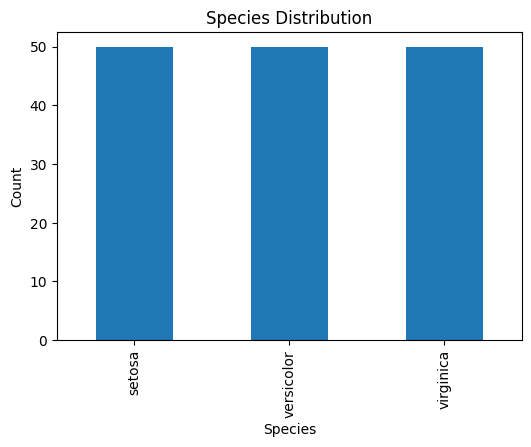

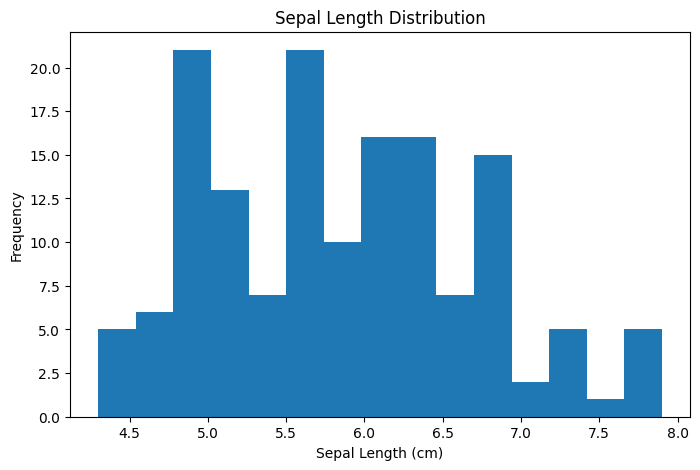

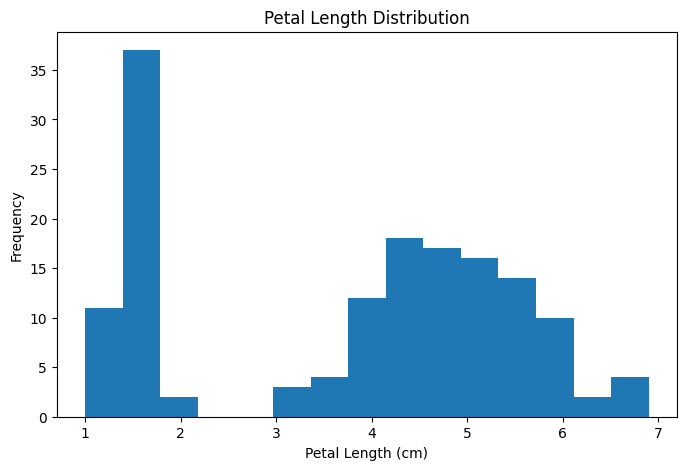

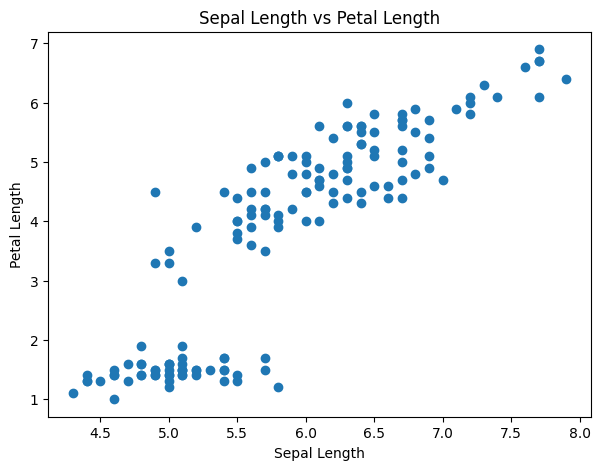

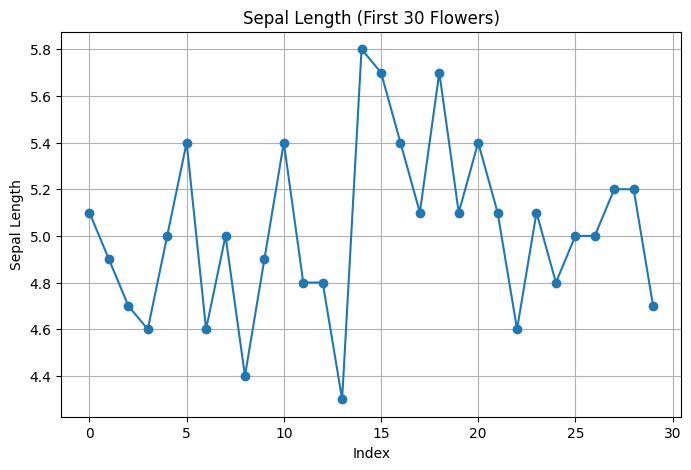

/tmp/ipykernel_3118/382673298.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


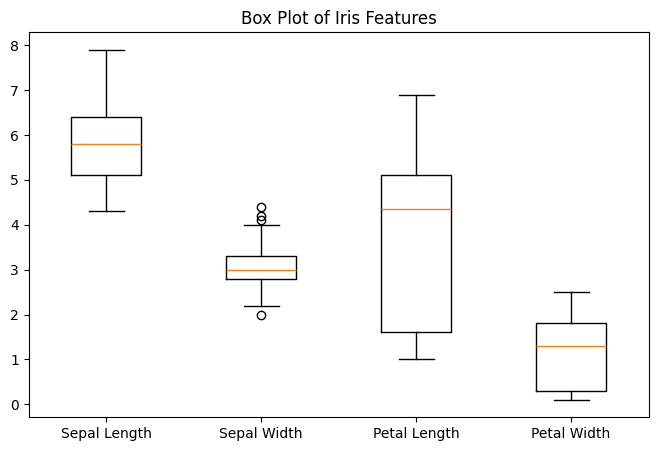

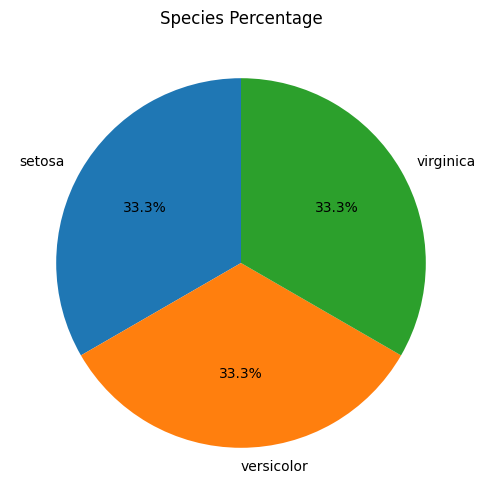


Correlation Matrix
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


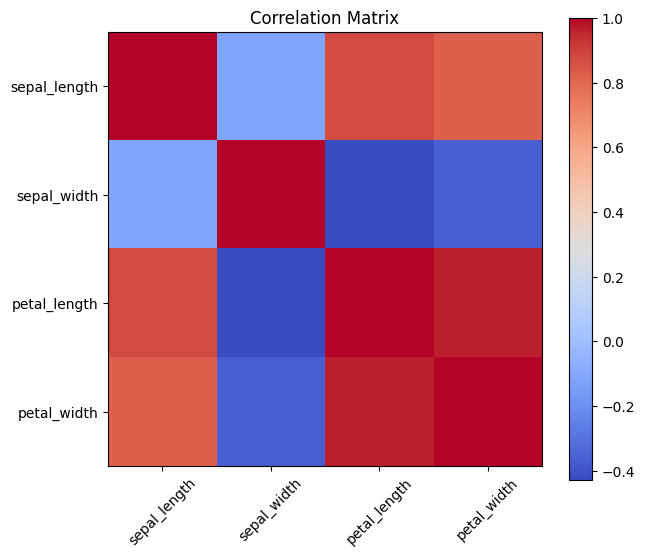


Average Measurements by Species
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026

Maximum Petal Length by Species
species
setosa        1.9
versicolor    5.1
virginica     6.9
Name: petal_length, dtype: float64

Minimum Sepal Width by Species
species
setosa        2.3
versicolor    2.0
virginica     2.2
Name: sepal_width, dtype: float64

Top 10 Flowers with Largest Petal Length
     sepal_length  sepal_width  petal_length  petal_width    species
118           7.7          2.6           6.9          2.3  virginica
117           7.7          3.8           6.7          2.2  virginica
122           7.7          2.8           6.7          2.0  virginica
105           7.6          3.0           6.6          2.1  virgini

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Load Dataset
# -----------------------------
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

df = pd.read_csv(url)

# -----------------------------
# Display Dataset
# -----------------------------
print("First 5 Records")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

# -----------------------------
# Basic Information
# -----------------------------
print("\nDataset Information")
print(df.info())

print("\nSummary Statistics")
print(df.describe())

# -----------------------------
# Missing Values
# -----------------------------
print("\nMissing Values")
print(df.isnull().sum())

# Fill missing values (if any)
df.fillna(df.mean(numeric_only=True), inplace=True)

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

# -----------------------------
# Species Distribution
# -----------------------------
species = df["species"].value_counts()

print("\nSpecies Count")
print(species)

plt.figure(figsize=(6,4))
species.plot(kind='bar')
plt.title("Species Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

# -----------------------------
# Sepal Length Distribution
# -----------------------------
plt.figure(figsize=(8,5))
plt.hist(df["sepal_length"], bins=15)

plt.title("Sepal Length Distribution")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Frequency")
plt.show()

# -----------------------------
# Petal Length Distribution
# -----------------------------
plt.figure(figsize=(8,5))
plt.hist(df["petal_length"], bins=15)

plt.title("Petal Length Distribution")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Frequency")
plt.show()

# -----------------------------
# Scatter Plot
# -----------------------------
plt.figure(figsize=(7,5))
plt.scatter(df["sepal_length"], df["petal_length"])

plt.title("Sepal Length vs Petal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.show()

# -----------------------------
# Line Plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(df.index[:30], df["sepal_length"][:30], marker='o')

plt.title("Sepal Length (First 30 Flowers)")
plt.xlabel("Index")
plt.ylabel("Sepal Length")
plt.grid(True)
plt.show()

# -----------------------------
# Box Plot
# -----------------------------
plt.figure(figsize=(8,5))

plt.boxplot([
    df["sepal_length"],
    df["sepal_width"],
    df["petal_length"],
    df["petal_width"]
],
labels=[
    "Sepal Length",
    "Sepal Width",
    "Petal Length",
    "Petal Width"
])

plt.title("Box Plot of Iris Features")
plt.show()

# -----------------------------
# Pie Chart
# -----------------------------
plt.figure(figsize=(6,6))

plt.pie(species,
        labels=species.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Species Percentage")
plt.show()

# -----------------------------
# Correlation Matrix
# -----------------------------
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

print("\nCorrelation Matrix")
print(correlation)

plt.figure(figsize=(7,6))
plt.imshow(correlation, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(correlation.columns)),
           correlation.columns,
           rotation=45)

plt.yticks(range(len(correlation.columns)),
           correlation.columns)

plt.title("Correlation Matrix")
plt.show()

# -----------------------------
# Group Analysis
# -----------------------------
print("\nAverage Measurements by Species")
print(df.groupby("species").mean(numeric_only=True))

print("\nMaximum Petal Length by Species")
print(df.groupby("species")["petal_length"].max())

print("\nMinimum Sepal Width by Species")
print(df.groupby("species")["sepal_width"].min())

# -----------------------------
# Top 10 Flowers with Largest Petal Length
# -----------------------------
print("\nTop 10 Flowers with Largest Petal Length")
print(df.nlargest(10, "petal_length"))

# -----------------------------
# Save Cleaned Dataset
# -----------------------------
df.to_csv("cleaned_iris.csv", index=False)

print("\nCleaned dataset saved successfully.")

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = {
    "Student":["Arun","Bala","Charan","Divya","Eswar","Farah","Gokul","Hari"],
    "Math":[85,78,92,88,76,95,80,89],
    "Science":[90,75,89,84,79,91,82,87],
    "English":[88,80,85,90,83,94,78,86],
    "Attendance":[95,90,98,92,88,99,91,96]
}

df = pd.DataFrame(data)

print(df)

  Student  Math  Science  English  Attendance
0    Arun    85       90       88          95
1    Bala    78       75       80          90
2  Charan    92       89       85          98
3   Divya    88       84       90          92
4   Eswar    76       79       83          88
5   Farah    95       91       94          99
6   Gokul    80       82       78          91
7    Hari    89       87       86          96


In [ ]:
plt.figure(figsize=(8,5))
plt.plot(df["Student"], df["Math"], marker='o')
plt.title("Math Marks")
plt.xlabel("Students")
plt.ylabel("Marks")
plt.grid(True)
plt.show()

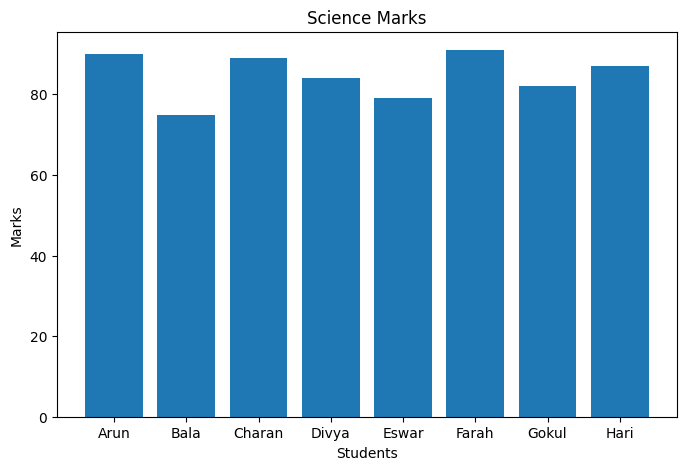

In [3]:
plt.figure(figsize=(8,5))
plt.bar(df["Student"], df["Science"])
plt.title("Science Marks")
plt.xlabel("Students")
plt.ylabel("Marks")
plt.show()

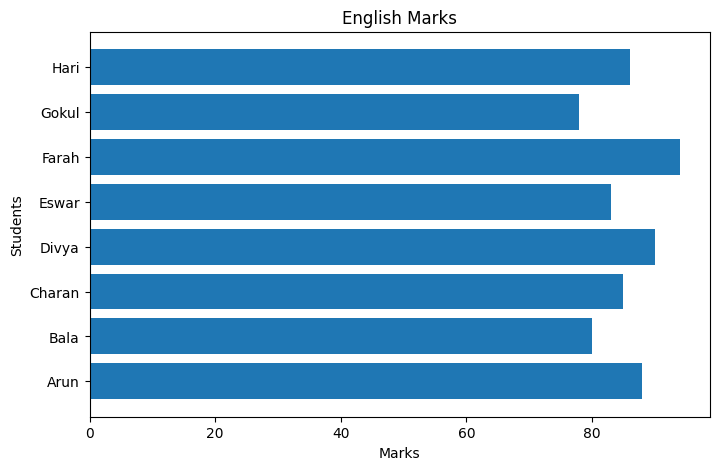

In [4]:
plt.figure(figsize=(8,5))
plt.barh(df["Student"], df["English"])
plt.title("English Marks")
plt.xlabel("Marks")
plt.ylabel("Students")
plt.show()

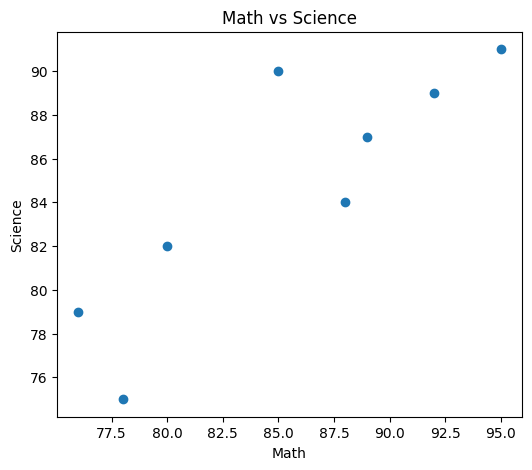

In [5]:
plt.figure(figsize=(6,5))
plt.scatter(df["Math"], df["Science"])
plt.title("Math vs Science")
plt.xlabel("Math")
plt.ylabel("Science")
plt.show()

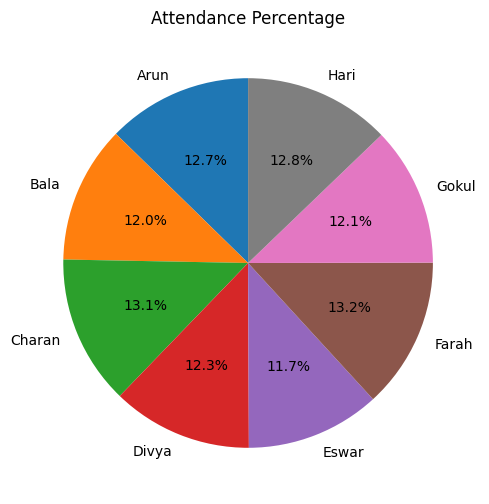

In [6]:
plt.figure(figsize=(6,6))
plt.pie(df["Attendance"],
        labels=df["Student"],
        autopct='%1.1f%%',
        startangle=90)
plt.title("Attendance Percentage")
plt.show()

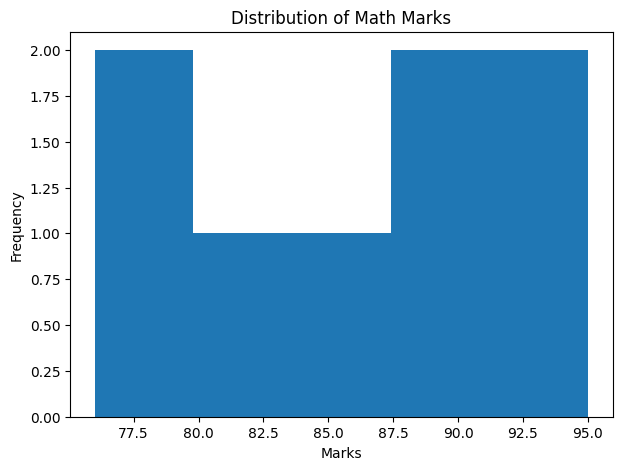

In [7]:
plt.figure(figsize=(7,5))
plt.hist(df["Math"], bins=5)
plt.title("Distribution of Math Marks")
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.show()

/tmp/ipykernel_3118/2992148583.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df["Math"], df["Science"], df["English"]],


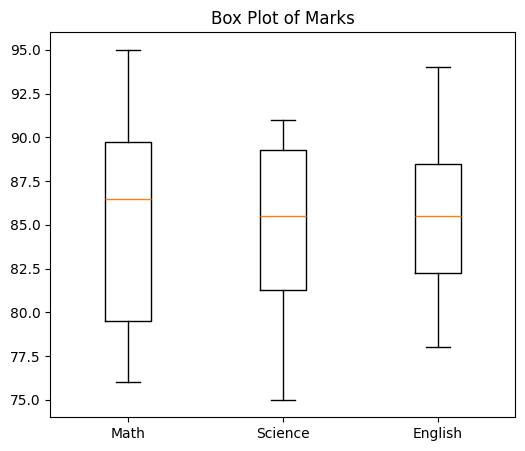

In [9]:
plt.figure(figsize=(6,5))
plt.boxplot([df["Math"], df["Science"], df["English"]],
            labels=["Math","Science","English"])
plt.title("Box Plot of Marks")
plt.show()

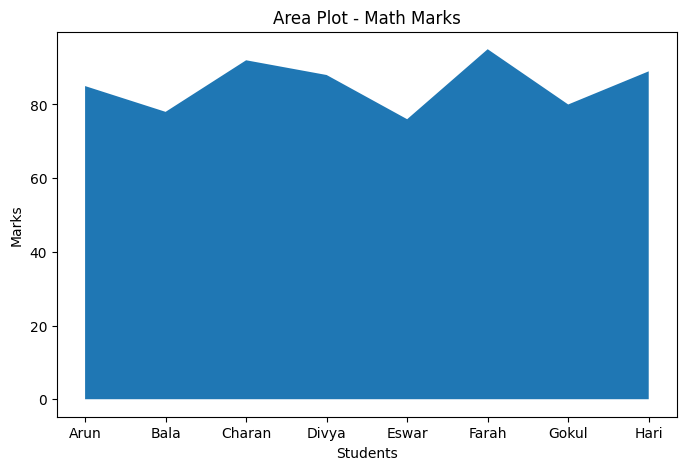

In [10]:
plt.figure(figsize=(8,5))
plt.fill_between(df["Student"], df["Math"])
plt.title("Area Plot - Math Marks")
plt.xlabel("Students")
plt.ylabel("Marks")
plt.show()

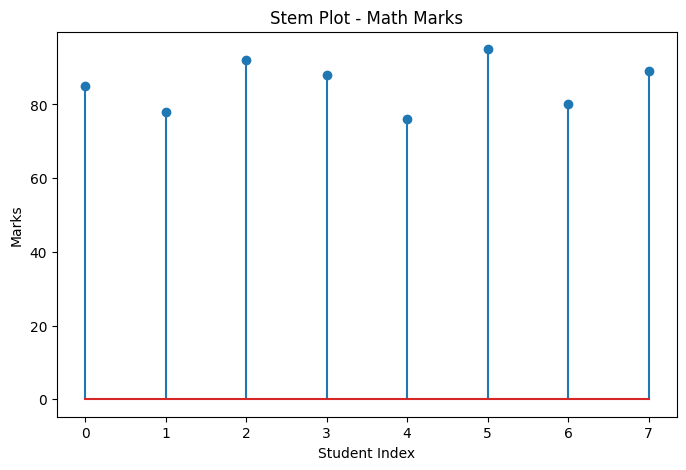

In [11]:
plt.figure(figsize=(8,5))
plt.stem(df["Math"])
plt.title("Stem Plot - Math Marks")
plt.xlabel("Student Index")
plt.ylabel("Marks")
plt.show()

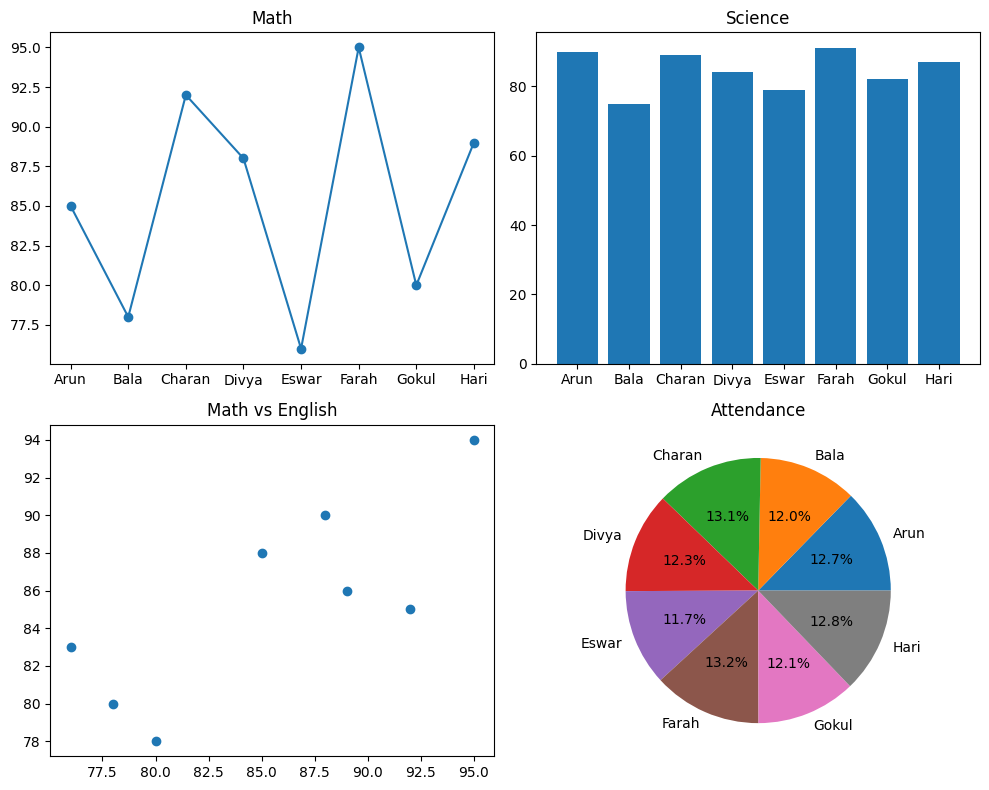

In [12]:
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.plot(df["Student"], df["Math"], marker='o')
plt.title("Math")

plt.subplot(2,2,2)
plt.bar(df["Student"], df["Science"])
plt.title("Science")

plt.subplot(2,2,3)
plt.scatter(df["Math"], df["English"])
plt.title("Math vs English")

plt.subplot(2,2,4)
plt.pie(df["Attendance"],
        labels=df["Student"],
        autopct='%1.1f%%')
plt.title("Attendance")

plt.tight_layout()
plt.show()

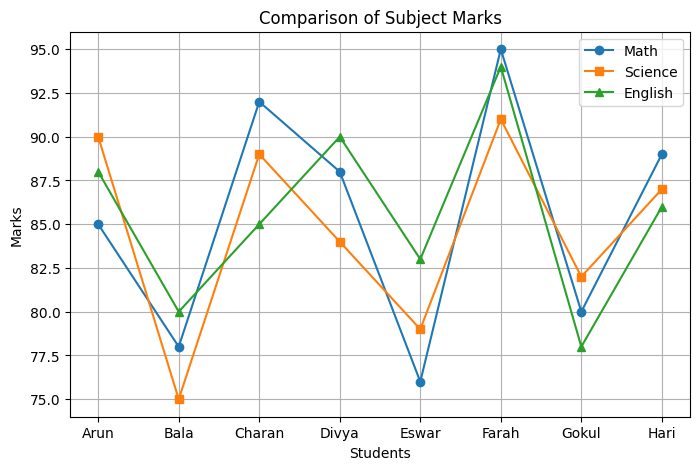

In [13]:
plt.figure(figsize=(8,5))

plt.plot(df["Student"], df["Math"], marker='o', label="Math")
plt.plot(df["Student"], df["Science"], marker='s', label="Science")
plt.plot(df["Student"], df["English"], marker='^', label="English")

plt.title("Comparison of Subject Marks")
plt.xlabel("Students")
plt.ylabel("Marks")
plt.legend()
plt.grid(True)

plt.show()

In [15]:
!pip install -q kaggle

from google.colab import files
files.upload()     # Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c titanic

!unzip titanic.zip

import pandas as pd

df = pd.read_csv("train.csv")
df.head()

Saving train.csv to train.csv
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication
unzip:  cannot find or open titanic.zip, titanic.zip.zip or titanic.zip.ZIP.


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
